# IP Practical (Data Visualization Day 1)
14-07-2026

## Question 1

You are provided with a structured dataset containing the academic results of Class XII students across different streams. Write a Python program using the `pandas` and `matplotlib` libraries to perform the following operations:

1. Create a DataFrame containing student data (Roll No, Name, Section, Stream, and marks in 4 subjects).

2. Calculate the 'Total Marks' and 'Percentage' for each student and add them as new columns.

3. Analyze the data by calculating the average percentage scored by each Section.

4. Generate a Bar Chart to visualize the Section-wise average percentage. Ensure the chart includes an appropriate title, X and Y-axis labels, and a legend.

--- Original Result Data ---
   RollNo    Name Section      Stream  English  Sub_2  Sub_3  Sub_4
0    2201   Aarav   XII-A     Science       88     95     92     98
1    2202  Bhavya   XII-A     Science       92     89     94     90
2    2203  Chirag   XII-A     Science       75     80     78     85
3    2204    Diya   XII-B    Commerce       85     90     85     95
4    2205  Eshaan   XII-B    Commerce       78     88     80     85
5    2206    Fiza   XII-C  Humanities       90     85     88     92
6    2207  Gaurav   XII-C  Humanities       85     82     79     88
7    2208    Hina   XII-C  Humanities       92     88     91     89


--- Data with Total and Percentage ---
     Name Section  Total  Percentage
0   Aarav   XII-A    373       93.25
1  Bhavya   XII-A    365       91.25
2  Chirag   XII-A    318       79.50
3    Diya   XII-B    355       88.75
4  Eshaan   XII-B    331       82.75
5    Fiza   XII-C    355       88.75
6  Gaurav   XII-C    334       83.50
7    Hina   XII-C    3

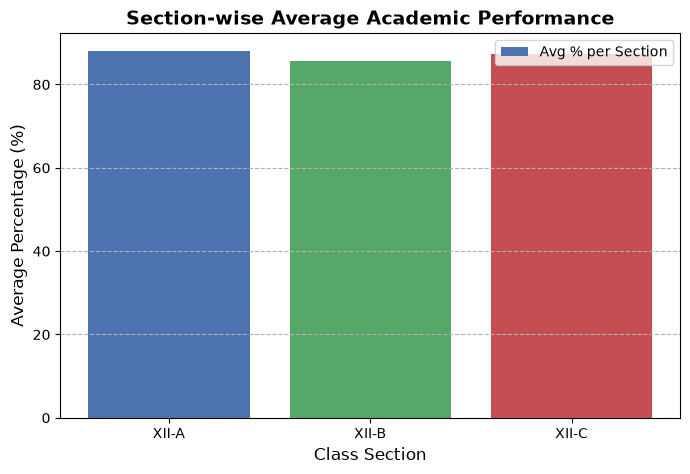

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Creating the DataFrame mimicking structured result data
data = {
    'RollNo': [2201, 2202, 2203, 2204, 2205, 2206, 2207, 2208],
    'Name': ['Aarav', 'Bhavya', 'Chirag', 'Diya', 'Eshaan', 'Fiza', 'Gaurav', 'Hina'],
    'Section': ['XII-A', 'XII-A', 'XII-A', 'XII-B', 'XII-B', 'XII-C', 'XII-C', 'XII-C'],
    'Stream': ['Science', 'Science', 'Science', 'Commerce', 'Commerce', 'Humanities', 'Humanities', 'Humanities'],
    'English': [88, 92, 75, 85, 78, 90, 85, 92],
    'Sub_2': [95, 89, 80, 90, 88, 85, 82, 88],
    'Sub_3': [92, 94, 78, 85, 80, 88, 79, 91],
    'Sub_4': [98, 90, 85, 95, 85, 92, 88, 89]
}

df = pd.DataFrame(data)
print("--- Original Result Data ---")
print(df)
print("\n")

# 2. Calculating Total Marks and Percentage
df['Total'] = df['English'] + df['Sub_2'] + df['Sub_3'] + df['Sub_4']
df['Percentage'] = (df['Total'] / 400) * 100

print("--- Data with Total and Percentage ---")
print(df[['Name', 'Section', 'Total', 'Percentage']])
print("\n")

# 3. Analyzing performance: Section-wise average percentage
section_analysis = df.groupby('Section')['Percentage'].mean().reset_index()
print("--- Section-wise Average Percentage ---")
print(section_analysis)

# 4. Plotting the Bar Chart
plt.figure(figsize=(8, 5))

# Extracting data for plotting
sections = section_analysis['Section']
averages = section_analysis['Percentage']

# Creating the bar chart
bars = plt.bar(sections, averages, 
               color=['#4C72B0', '#55A868', '#C44E52'], label='Avg % per Section')

# Adding Titles and Labels
plt.title('Section-wise Average Academic Performance', fontsize=14, fontweight='bold')
plt.xlabel('Class Section', fontsize=12)
plt.ylabel('Average Percentage (%)', fontsize=12)

# Adding a legend
plt.legend()

# Adding gridlines for better readability
plt.grid(axis='y', linestyle='--')

# Displaying the plot
plt.show()

## Question 2
You have downloaded a dataset from an open-source portal (e.g., data.gov.in) detailing the annual renewable energy capacity (in Megawatts) installed across different Indian states over three years.

1. Load this data into a Pandas DataFrame.

2. Aggregate the data to find the total renewable energy capacity installed by each state over the given years.

3. Summarize the year-wise total national capacity.

4. Plot a Bar Chart comparing the state-wise total renewable energy capacity. Ensure the chart includes an appropriate title, X and Y-axis labels, and distinct bar colors.

5. Plot a Line Chart showing the year-wise growth in national capacity. Include markers, titles, and legends.

--- State-wise Total Renewable Capacity (MW) ---
State
Gujarat        5300
Karnataka      7000
Maharashtra    4550
Rajasthan      7900
Tamil Nadu     5950
Name: Capacity_MW, dtype: int64


--- Year-wise National Capacity (MW) ---
Year
2021     8800
2022    10000
2023    11900
Name: Capacity_MW, dtype: int64


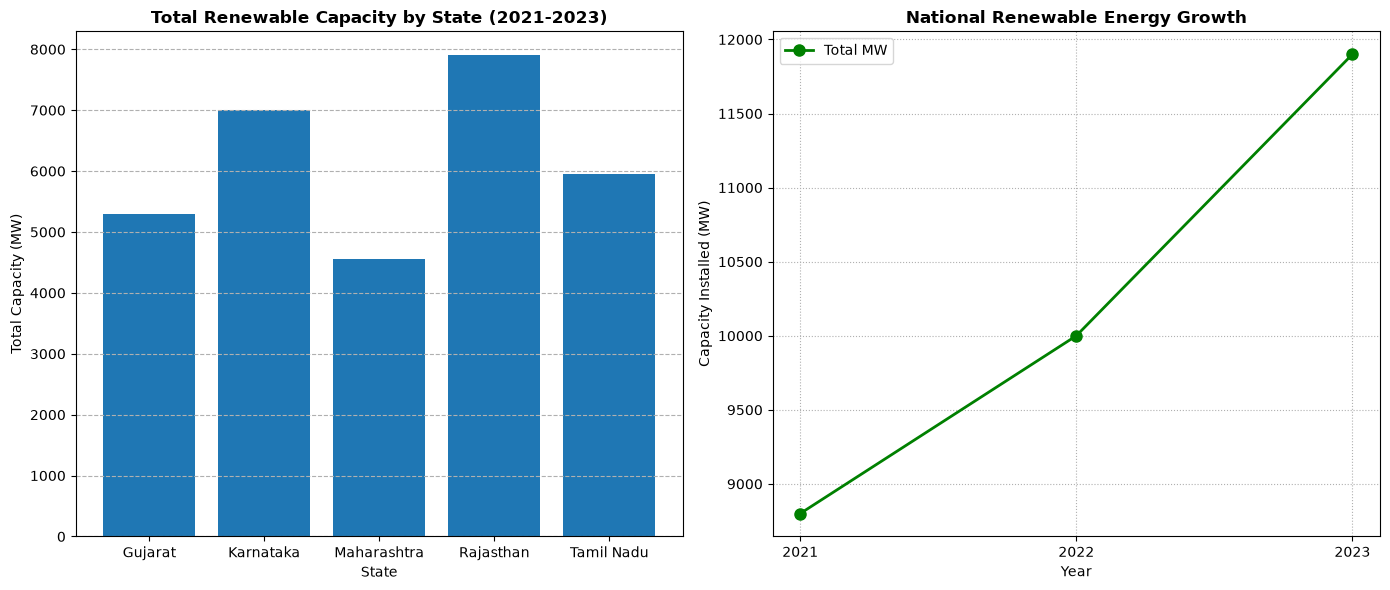

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Creating DataFrame mimicking open-source government data
gov_data = {
    'State': ['Gujarat', 'Tamil Nadu', 'Karnataka', 'Rajasthan', 'Maharashtra', 
              'Gujarat', 'Tamil Nadu', 'Karnataka', 'Rajasthan', 'Maharashtra',
              'Gujarat', 'Tamil Nadu', 'Karnataka', 'Rajasthan', 'Maharashtra'],
    'Year': [2021, 2021, 2021, 2021, 2021, 
             2022, 2022, 2022, 2022, 2022, 
             2023, 2023, 2023, 2023, 2023],
    'Capacity_MW': [1500, 1800, 2000, 2200, 1300, 
                    1700, 1950, 2300, 2600, 1450, 
                    2100, 2200, 2700, 3100, 1800]
}

df_energy = pd.DataFrame(gov_data)

# 2. Aggregating data: Total capacity installed by each state
state_total = df_energy.groupby('State')['Capacity_MW'].sum()
print("--- State-wise Total Renewable Capacity (MW) ---")
print(state_total)
print("\n")

# 3. Summarizing data: Year-wise total national capacity
year_total = df_energy.groupby('Year')['Capacity_MW'].sum()
print("--- Year-wise National Capacity (MW) ---")
print(year_total)

# 4 & 5. Plotting the Charts

# Set up a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: Bar Chart for State-wise contribution
states = state_total.index
capacities = state_total.values
ax1.bar(states, capacities)
ax1.set_title('Total Renewable Capacity by State (2021-2023)', fontweight='bold')
ax1.set_xlabel('State')
ax1.set_ylabel('Total Capacity (MW)')
ax1.grid(axis='y', linestyle='--')

# Plot B: Line Chart for Year-wise national growth
ax2.plot(year_total.index, year_total.values, marker='o', color='green', 
         linestyle='-', linewidth=2, markersize=8, label='Total MW')
ax2.set_title('National Renewable Energy Growth', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Capacity Installed (MW)')
# Force X-axis to show only the specific integer years
ax2.set_xticks([2021, 2022, 2023])
ax2.grid(True, linestyle=':')
ax2.legend()

# Adjust layout and display
plt.tight_layout()
plt.show()